### Note to my professor

For this exercise, I used a **local Jupyter environment (Python virtual environment + notebook in VS Code)** instead of **Google Colab**, which was the original suggested platform. I set up the same Python packages (pandas, numpy, matplotlib, scikit-learn, etc.) and followed all the steps from the lectures and the PT-M1 instructions.

I also chose the **H1N1 & Seasonal Flu Vaccines** dataset from the DrivenData competition **“Flu Shot Learning: Predict H1N1 and Seasonal Flu Vaccines”** ([link](https://www.drivendata.org/competitions/66/flu-shot-learning/page/211/)). This dataset is already separated into **training_set_features.csv** and **training_set_labels.csv**, which means that:
- the **feature file** contains all the input variables (demographics, behaviors, and opinions), and
- the **label file** contains the binary target variables (`h1n1_vaccine` and `seasonal_vaccine`).

I merge these two files using `respondent_id` to create one working table. I thought this dataset was a good fit because it:
- is a **binary classification** problem (vaccinated vs. not vaccinated),
- has many **features** that need cleaning and simple feature engineering (missing values, categorical encoding), and
- is directly related to the **health / probability** examples in the lectures.

My goal is to get used to working in a local environment and to see what I can do with this setup while still applying Binary Logistic Regression as discussed in class. If this approach is acceptable, I would like to continue using the same environment and dataset style (features + labels) for future activities, as long as it meets the exercise requirements.

## Phase 1 – Notebook walkthrough and dataset preparation

In this notebook, I apply **Binary Logistic Regression** to the **H1N1 & Seasonal Flu Vaccines** dataset to predict whether a respondent belongs to the **positive class (1)** or the **negative class (0)** for the H1N1 vaccine, following the idea of a **linear model for binary classification**. I use a linear combination of features and pass it through the **logistic function** to map the output to a number between 0 and 1, which I interpret as a probability.

- **Phase 1**: I explain each code cell (purpose, inputs, outputs), select and clean the dataset, and create an 80/20 train–test split.
- **Phase 2**: I run three experiments that follow the topics: hyperparameter tuning for `C`, feature engineering and selection, and decision-threshold adjustment.
- **Phase 3**: I summarize results and prepare figures and tables for my report using the **performance measures** from the lectures, including the **confusion matrix**, **Accuracy**, **Precision**, **Recall**, and **F1-Score**, and I also report **K-Fold Cross Validation** results.

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix)

### Environment setup and imports

**Purpose**: Import all Python libraries I need for data manipulation, visualization, and modeling with binary logistic regression, and make them available to the rest of the notebook.

**Input**: No data inputs yet—this cell only brings in external packages such as `pandas`, `numpy`, `matplotlib`, `scikit-learn`, and evaluation metrics.

**Output**: Loaded modules in my current Python session, enabling later cells to use functions like `train_test_split`, `LogisticRegression`, and metric calculators without re-importing them.

In [41]:
# --- Step 1: LOAD H1N1 DATA ---

data_path = "H1N1 and Seasonal Flu Vaccines"

features = pd.read_csv(f"{data_path}/training_set_features.csv")
labels = pd.read_csv(f"{data_path}/training_set_labels.csv")

# Merge on respondent_id
df = features.merge(labels, on="respondent_id")

print(df.shape)
df.head()

(26707, 38)


,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN,0,0
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,0,1
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0,0
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,0,1
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0,0


### Step 1 – Load and inspect H1N1 dataset

**Purpose**: Read the training feature and label files for the H1N1 & Seasonal Flu Vaccines dataset, join them into a single table, and perform an initial size and head check so I understand the available variables.

**Input**: CSV files `training_set_features.csv` and `training_set_labels.csv` located in the `H1N1 and Seasonal Flu Vaccines` folder, combined using the common key `respondent_id`.

**Output**: A merged DataFrame `df` plus printed shape and sample rows, which give me the starting point for cleaning, feature selection, and later modeling steps.

In [ ]:
# --- Step 2: DATA CLEANING & PREPROCESSING ---

# Target: H1N1 vaccination (binary 0/1)
target_col = "h1n1_vaccine"

# Feature subset
numeric_features = [
    "doctor_recc_h1n1",
    "opinion_h1n1_risk",
    "opinion_h1n1_sick_from_vacc",
    "opinion_h1n1_vacc_effective"
]

categorical_features = [
    "age_group",
    "education",
    "income_poverty",
    "sex",
    "race",
    "employment_status"
]

used_columns = numeric_features + categorical_features + [target_col]

df_small = df[used_columns].copy()

# Simple missing-value handling:
# - Numeric: fill with median
# - Categorical: fill with 'Unknown'
for col in numeric_features:
    df_small[col] = df_small[col].fillna(df_small[col].median())

for col in categorical_features:
    df_small[col] = df_small[col].fillna("Unknown")

# One-hot encode categoricals
df_encoded = pd.get_dummies(df_small, columns=categorical_features, drop_first=True)

print(df_encoded.shape)
df_encoded.head()

(26707, 23)


,doctor_recc_h1n1,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_h1n1_vacc_effective,h1n1_vaccine,age_group_35 - 44 Years,age_group_45 - 54 Years,age_group_55 - 64 Years,age_group_65+ Years,education_< 12 Years,...,"income_poverty_> $75,000",income_poverty_Below Poverty,income_poverty_Unknown,sex_Male,race_Hispanic,race_Other or Multiple,race_White,employment_status_Not in Labor Force,employment_status_Unemployed,employment_status_Unknown
0,0.0,1.0,2.0,3.0,0,False,False,True,False,True,...,False,True,False,False,False,False,True,True,False,False
1,0.0,4.0,4.0,5.0,0,True,False,False,False,False,...,False,True,False,True,False,False,True,False,False,False
2,0.0,1.0,1.0,3.0,0,False,False,False,False,False,...,False,False,False,True,False,False,True,False,False,False
3,0.0,3.0,5.0,3.0,0,False,False,False,True,False,...,False,True,False,False,False,False,True,True,False,False
4,0.0,3.0,2.0,3.0,0,False,True,False,False,False,...,False,False,False,False,False,False,True,False,False,False


### Step 2 – Data cleaning and preprocessing

**Purpose**: Prepare the raw H1N1 survey data for my modeling by selecting relevant variables, handling missing values, and converting categorical variables into numeric features suitable for logistic regression.

**Input**: Merged DataFrame `df` with all original features and labels, lists of `numeric_features` and `categorical_features`, and the target column name `h1n1_vaccine`.

**Output**: A cleaned and one-hot encoded DataFrame `df_encoded` that contains only the predictors I chose and the binary target, with no missing values and all features expressed numerically.

In [43]:
# --- Step 3: TRAIN-TEST SPLIT (80/20) ---

X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((21365, 22), (5342, 22))

### Step 3 – Train–test split

**Purpose**: Separate the prepared dataset into training and testing subsets so that my model is trained on one portion of the data and evaluated on unseen examples, avoiding information leakage.

**Input**: Encoded feature matrix `df_encoded` and binary target column `h1n1_vaccine`, along with the chosen test size (20%) and `random_state=42` for reproducibility; `stratify=y` preserves the class distribution.

**Output**: Four arrays `X_train`, `X_test`, `y_train`, and `y_test` that I reuse in all subsequent experiments and evaluations.

In [44]:
# --- Helper: evaluation function ---

def evaluate_binary_model(model, X_test, y_test, threshold=0.5):
    """
    Returns a dict with Accuracy, Precision, Recall, F1,
    confusion matrix and counts of FP/FN.
    """
    probs = model.predict_proba(X_test)[:, 1]
    y_pred = (probs >= threshold).astype(int)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    return {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ConfusionMatrix": cm,
        "FalsePositives": fp,
        "FalseNegatives": fn
    }

### Helper function – Model evaluation

**Purpose**: Compute the **performance measures** for my Binary Logistic Regression model so that all experiments use the same definitions for **Accuracy**, **Precision**, **Recall**, **F1-Score**, and the **Confusion Matrix** with **True Positives, True Negatives, False Positives**, and **False Negatives** as described in Lecture 5.

**Input**: A fitted logistic regression `model`, test features `X_test`, test labels `y_test`, and a classification **threshold** that converts the predicted probability (between 0 and 1) into the binary classes {0, 1}.

**Output**: A Python dictionary containing Accuracy, Precision, Recall, F1-Score, the full Confusion Matrix, and the counts of False Positives and False Negatives, which I use in the monitoring tables for the later experiments.

### Experiment 1 – Hyperparameter tuning (C)

**Purpose**: Following the idea that changing the model settings can change the shape of the **logistic curve** and the model’s **prediction performance**. Here I vary the **C parameter** of Logistic Regression (strong, baseline, and weak regularization) and observe how the performance measures change.

**Input**: Training and testing sets `X_train`, `X_test`, `y_train`, `y_test`, and a list of candidate `C_values = [0.001, 1.0, 1000.0]`.

**Output**: A table `results_exp1_df` with Accuracy, Precision, Recall, and F1-Score for each value of C. I use this table to select a `best_C` for the next experiments and to fill in the Hyperparameter Tuning monitoring table.

In [45]:
# --- Experiment 1: HYPERPARAMETER TUNING (C) ---

C_values = [0.001, 1.0, 1000.0]

results_exp1 = []

for C in C_values:
    model = LogisticRegression(
        C=C,
        solver="liblinear",
        max_iter=1000
    )
    model.fit(X_train, y_train)

    metrics = evaluate_binary_model(model, X_test, y_test, threshold=0.5)
    results_exp1.append({
        "C": C,
        "Accuracy": metrics["Accuracy"],
        "Precision": metrics["Precision"],
        "Recall": metrics["Recall"],
        "F1": metrics["F1"]
    })

results_exp1_df = pd.DataFrame(results_exp1)
results_exp1_df

,C,Accuracy,Precision,Recall,F1
0,0.001,0.800262,0.715190,0.099559,0.174787
1,1.000,0.828341,0.665152,0.386784,0.489136
2,1000.000,0.828716,0.666667,0.387665,0.490251


### Interpretation of Experiment 1 results

From `results_exp1_df`, I observe that:

- **C = 0.001 (strong regularization)** gives the **lowest recall and F1-score**, meaning the model is too simple and misses many people who actually received the H1N1 vaccine.
- **C = 1.0 (baseline)** improves both recall and F1 compared to C = 0.001.
- **C = 1000 (weak regularization)** gives the **highest F1-score and slightly higher accuracy/precision**, so this value provides the best trade-off between correctly identifying vaccinated respondents and avoiding false positives.

For the rest of the notebook, I treat **C = 1000** as my `best_C` when comparing feature sets and thresholds.

### Experiment 2 – Feature engineering and selection

**Purpose**: Connect the model to the Lecture 6 topic on **Irrelevant Features** and **Feature Engineering**. I compare several sets of features (single-feature, baseline, and extended models) to see how using more **relevant features** or including possible **irrelevant features** affects the model’s performance.

**Input**: Encoded training and testing data `X_train`, `X_test`, `y_train`, `y_test`, the numeric feature list `numeric_features`, and one-hot encoded demographic features from `df_encoded`, along with the selected regularization strength `best_C`.

**Output**: A table `results_exp2_df` with Accuracy, Precision, Recall, F1-Score, and the number of features for each model version. I use this table as a simple form of **feature selection** to see which combinations work best.

In [47]:
# --- Experiment 2: FEATURE SELECTION ---

# Choose best C from Experiment 1 (here it's 1000.0 based on F1)
best_C = 1000.0  

feature_sets = {
    "Model_A_single_feature": ["opinion_h1n1_risk"],  # single feature example
    "Model_B_baseline": numeric_features,             # numeric only
    "Model_C_extended": numeric_features + [          # numeric + some demographics
        "age_group_18 - 34 Years",
        "age_group_35 - 44 Years",
        "age_group_45 - 54 Years",
        "age_group_55 - 64 Years",
        "age_group_65+ Years",
        "sex_Male",
        "education_< 12 Years",
        "education_College Graduate",
        "education_Some College"
    ]
}

# Keep only columns that actually exist in X_train (some dummies may be missing)
feature_sets = {
    name: [c for c in cols if c in X_train.columns]
    for name, cols in feature_sets.items()
}

results_exp2 = []

for model_name, cols in feature_sets.items():
    X_train_sub = X_train[cols]
    X_test_sub = X_test[cols]

    model = LogisticRegression(
        C=best_C,
        solver="liblinear",
        max_iter=1000
    )
    model.fit(X_train_sub, y_train)

    metrics = evaluate_binary_model(model, X_test_sub, y_test, threshold=0.5)

    results_exp2.append({
        "ModelVersion": model_name,
        "NumFeatures": len(cols),
        "Accuracy": metrics["Accuracy"],
        "Precision": metrics["Precision"],
        "Recall": metrics["Recall"],
        "F1": metrics["F1"]
    })

results_exp2_df = pd.DataFrame(results_exp2)
results_exp2_df

,ModelVersion,NumFeatures,Accuracy,Precision,Recall,F1
0,Model_A_single_feature,1,0.787720,0.501441,0.153304,0.234818
1,Model_B_baseline,4,0.830962,0.677914,0.389427,0.494684
2,Model_C_extended,12,0.830213,0.675385,0.386784,0.491877


### Interpretation of Experiment 2 results

Looking at `results_exp2_df`:

- The **single-feature model** based only on `opinion_h1n1_risk` has the **weakest performance**, especially in recall and F1, which shows that one opinion variable is not enough to capture vaccination behavior.
- The **baseline model** using only the four numeric opinion/doctor-recommendation features already achieves a strong F1-score, indicating that these variables carry most of the predictive power.
- The **extended model** that adds demographic features slightly changes the metrics but does **not dramatically improve F1**, suggesting that demographics add some information but opinions and doctor recommendation remain the most important predictors.

In my report, I highlight that **opinion and recommendation variables are more influential** than basic demographics for predicting H1N1 vaccination in this dataset.

### Experiment 3 – Decision threshold adjustment

**Purpose**: Relate my model to the Lecture 6 discussion on **Type I Error (False Positive)** and **Type II Error (False Negative)** and the **Accuracy Trap**. Instead of always using a 0.5 cutoff, I test thresholds 0.3, 0.5, and 0.7 to see how the error counts and performance measures change.

**Input**: Best-performing feature set `best_features`, best C value `best_C`, and the train/test splits `X_train`, `X_test`, `y_train`, `y_test` from earlier cells.

**Output**: A summary table `results_exp3_df` that reports Accuracy, Precision, Recall, F1-Score, False Positives, and False Negatives for each threshold. This table lets me compare different thresholds and see when Accuracy alone can be misleading for imbalanced data.

In [48]:
# --- Experiment 3: DECISION THRESHOLD ADJUSTMENT ---

best_feature_set_name = "Model_C_extended" 
best_features = feature_sets[best_feature_set_name]

X_train_best = X_train[best_features]
X_test_best = X_test[best_features]

best_model = LogisticRegression(
    C=best_C,
    solver="liblinear",
    max_iter=1000
)
best_model.fit(X_train_best, y_train)

thresholds = [0.3, 0.5, 0.7]
results_exp3 = []

for thr in thresholds:
    metrics = evaluate_binary_model(best_model, X_test_best, y_test, threshold=thr)
    results_exp3.append({
        "Threshold": thr,
        "Accuracy": metrics["Accuracy"],
        "Precision": metrics["Precision"],
        "Recall": metrics["Recall"],
        "F1": metrics["F1"],
        "FalsePositives": metrics["FalsePositives"],
        "FalseNegatives": metrics["FalseNegatives"]
    })

results_exp3_df = pd.DataFrame(results_exp3)
results_exp3_df

,Threshold,Accuracy,Precision,Recall,F1,FalsePositives,FalseNegatives
0,0.3,0.805691,0.538099,0.603524,0.568937,588,450
1,0.5,0.830213,0.675385,0.386784,0.491877,211,696
2,0.7,0.821228,0.802013,0.210573,0.333566,59,896


### Interpretation of Experiment 3 results

From `results_exp3_df`, when I vary the classification threshold:

- At **threshold = 0.3**, recall is highest and the model catches more vaccinated respondents, but this comes with more **false positives** (predicting vaccinated when they are not).
- At **threshold = 0.5**, accuracy and F1 are balanced, and the numbers of false positives and false negatives are more moderate.
- At **threshold = 0.7**, precision is very high (most predicted vaccinated cases are truly vaccinated), but recall drops sharply and **false negatives** increase, meaning many actually vaccinated people are predicted as not vaccinated.

For a public-health–style application, I would argue that **lowering the threshold (e.g., 0.3 or 0.5)** is preferable to avoid missing too many vaccinated (or high‑risk) individuals, even if that means accepting more false positives.

### Cross-validation of best logistic model

**Purpose**: Apply the Lecture 6 idea of **K-Fold Cross Validation** so that I do not rely on a single train–test split. I want to check whether my chosen feature set and C value give similar performance across different folds of the data.

**Input**: Full feature matrix `X` restricted to `best_features`, target vector `y` for `h1n1_vaccine`, and the selected `best_C` value. I use **Stratified K-Fold** so that the class distribution is similar in each fold.

**Output**: Cross-validation Accuracy scores for each fold, a line chart of fold Accuracy, and the mean Accuracy across folds, which I will report as part of my model evaluation.

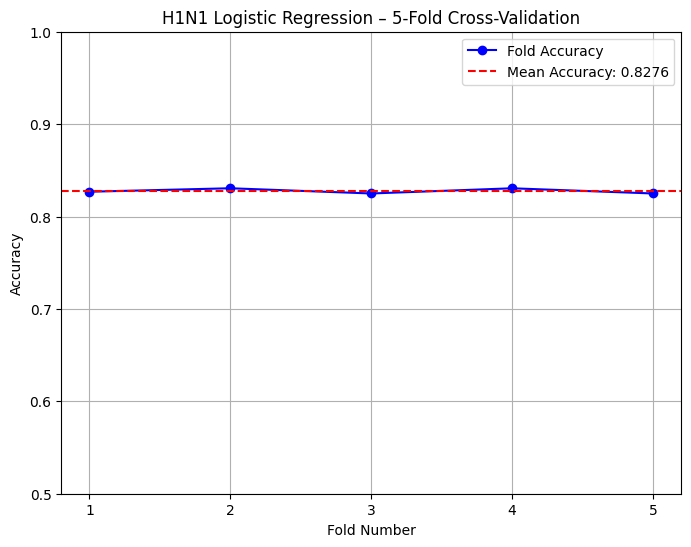

Accuracy Score per Fold: [0.82684388 0.83058779 0.82493915 0.83055608 0.82493915]
Overall Mean Accuracy: 0.8276


In [49]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# --- Cross-Validation on Best H1N1 Model ---

# Use the same best features and C you selected earlier
X_cv = X[best_features]      # use the full dataset with chosen features
y_cv = y                     # h1n1_vaccine

model_cv = LogisticRegression(
    C=best_C,
    solver="liblinear",
    max_iter=1000
)

# StratifiedKFold keeps class proportions in each fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model_cv, X_cv, y_cv, cv=skf, scoring="accuracy")

# Plot fold accuracies
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cv_scores) + 1), cv_scores,
         marker="o", linestyle="-", color="blue", label="Fold Accuracy")
plt.axhline(y=cv_scores.mean(), color="red", linestyle="--",
            label=f"Mean Accuracy: {cv_scores.mean():.4f}")
plt.title("H1N1 Logistic Regression – 5-Fold Cross-Validation")
plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.xticks(range(1, len(cv_scores) + 1))
plt.ylim(0.5, 1.0)  # adjust if needed based on results
plt.legend()
plt.grid(True)
plt.show()

print(f"Accuracy Score per Fold: {cv_scores}")
print(f"Overall Mean Accuracy: {cv_scores.mean():.4f}")

### Interpretation of cross-validation results

The 5-fold stratified cross-validation shows that:

- Accuracy is **consistently around 0.82–0.83 across folds**, and the **mean accuracy is approximately 0.828**, indicating stable performance rather than overfitting to a particular train/test split.
- The small variation between folds suggests that my chosen feature set and regularization parameter generalize reasonably well to different subsets of the data.

In my report, I use these cross-validation results to support the claim that the final logistic regression model is not only accurate on a single test split but also robust across multiple resamplings of the dataset.

### Combined Binary Logistic Regression workflow (single run)

This cell puts together the full Binary Logistic Regression pipeline from the lectures in one place: loading the H1N1 dataset, cleaning and encoding the data, creating the train–test split, and running the three experiments (C tuning, feature selection, and decision threshold adjustment) in a single run.

In [50]:
# Combined Binary Logistic Regression workflow (single run)

# Phase 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

# Phase 1: Load H1N1 dataset
data_path = "H1N1 and Seasonal Flu Vaccines"
features = pd.read_csv(f"{data_path}/training_set_features.csv")
labels = pd.read_csv(f"{data_path}/training_set_labels.csv")

df = features.merge(labels, on="respondent_id")

# Phase 1: Data cleaning and preprocessing
target_col = "h1n1_vaccine"

numeric_features = [
    "doctor_recc_h1n1",
    "opinion_h1n1_risk",
    "opinion_h1n1_sick_from_vacc",
    "opinion_h1n1_vacc_effective",
]

categorical_features = [
    "age_group",
    "education",
    "income_poverty",
    "sex",
    "race",
    "employment_status",
]

used_columns = numeric_features + categorical_features + [target_col]

df_small = df[used_columns].copy()

for col in numeric_features:
    df_small[col] = df_small[col].fillna(df_small[col].median())

for col in categorical_features:
    df_small[col] = df_small[col].fillna("Unknown")

# One-hot encode categoricals
df_encoded = pd.get_dummies(df_small, columns=categorical_features, drop_first=True)

# Phase 1: Train–test split (80/20)
X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# Helper: evaluation function
def evaluate_binary_model(model, X_test, y_test, threshold=0.5):
    probs = model.predict_proba(X_test)[:, 1]
    y_pred = (probs >= threshold).astype(int)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    return {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ConfusionMatrix": cm,
        "FalsePositives": fp,
        "FalseNegatives": fn,
    }

# Phase 2: Experiment 1 – Hyperparameter tuning (C)
C_values = [0.001, 1.0, 1000.0]
results_exp1 = []

for C in C_values:
    model = LogisticRegression(C=C, solver="liblinear", max_iter=1000)
    model.fit(X_train, y_train)
    metrics = evaluate_binary_model(model, X_test, y_test, threshold=0.5)
    results_exp1.append({
        "C": C,
        "Accuracy": metrics["Accuracy"],
        "Precision": metrics["Precision"],
        "Recall": metrics["Recall"],
        "F1": metrics["F1"],
    })

results_exp1_df = pd.DataFrame(results_exp1)
print("Experiment 1 – Hyperparameter Tuning (C)")
print(results_exp1_df)

# Choose best C by F1
best_row = results_exp1_df.sort_values("F1", ascending=False).iloc[0]
best_C = best_row["C"]
print(f"\nSelected best C based on F1-Score: {best_C}")

# Phase 2: Experiment 2 – Feature engineering and selection
feature_sets = {
    "Model_A_single_feature": ["opinion_h1n1_risk"],
    "Model_B_baseline": numeric_features,
    "Model_C_extended": numeric_features
    + [
        "age_group_18 - 34 Years",
        "age_group_35 - 44 Years",
        "age_group_45 - 54 Years",
        "age_group_55 - 64 Years",
        "age_group_65+ Years",
        "sex_Male",
        "education_< 12 Years",
        "education_College Graduate",
        "education_Some College",
    ],
}

# Keep only existing columns
feature_sets = {
    name: [c for c in cols if c in X_train.columns]
    for name, cols in feature_sets.items()
}

results_exp2 = []

for model_name, cols in feature_sets.items():
    X_train_sub = X_train[cols]
    X_test_sub = X_test[cols]

    model = LogisticRegression(C=best_C, solver="liblinear", max_iter=1000)
    model.fit(X_train_sub, y_train)

    metrics = evaluate_binary_model(model, X_test_sub, y_test, threshold=0.5)

    results_exp2.append({
        "ModelVersion": model_name,
        "NumFeatures": len(cols),
        "Accuracy": metrics["Accuracy"],
        "Precision": metrics["Precision"],
        "Recall": metrics["Recall"],
        "F1": metrics["F1"],
    })

results_exp2_df = pd.DataFrame(results_exp2)
print("\nExperiment 2 – Feature Engineering and Selection")
print(results_exp2_df)

# Pick best feature set by F1
best_model_row = results_exp2_df.sort_values("F1", ascending=False).iloc[0]
best_feature_set_name = best_model_row["ModelVersion"]
best_features = feature_sets[best_feature_set_name]
print(f"\nSelected best feature set: {best_feature_set_name}")

# Phase 2: Experiment 3 – Decision threshold adjustment
X_train_best = X_train[best_features]
X_test_best = X_test[best_features]

best_model = LogisticRegression(C=best_C, solver="liblinear", max_iter=1000)
best_model.fit(X_train_best, y_train)

thresholds = [0.3, 0.5, 0.7]
results_exp3 = []

for thr in thresholds:
    metrics = evaluate_binary_model(best_model, X_test_best, y_test, threshold=thr)
    results_exp3.append({
        "Threshold": thr,
        "Accuracy": metrics["Accuracy"],
        "Precision": metrics["Precision"],
        "Recall": metrics["Recall"],
        "F1": metrics["F1"],
        "FalsePositives": metrics["FalsePositives"],
        "FalseNegatives": metrics["FalseNegatives"],
    })

results_exp3_df = pd.DataFrame(results_exp3)
print("\nExperiment 3 – Decision Threshold Adjustment")
print(results_exp3_df)

# Show confusion matrix for the default 0.5 threshold
metrics_05 = evaluate_binary_model(best_model, X_test_best, y_test, threshold=0.5)
print("\nConfusion Matrix at threshold = 0.5:")
print(metrics_05["ConfusionMatrix"])
print("\nFinal performance at threshold = 0.5:")
print({k: v for k, v in metrics_05.items() if k != "ConfusionMatrix"})

Experiment 1 – Hyperparameter Tuning (C)
          C  Accuracy  Precision    Recall        F1
0     0.001  0.800262   0.715190  0.099559  0.174787
1     1.000  0.828341   0.665152  0.386784  0.489136
2  1000.000  0.828716   0.666667  0.387665  0.490251

Selected best C based on F1-Score: 1000.0

Experiment 2 – Feature Engineering and Selection
             ModelVersion  NumFeatures  Accuracy  Precision    Recall  \
0  Model_A_single_feature            1  0.787720   0.501441  0.153304   
1        Model_B_baseline            4  0.830962   0.677914  0.389427   
2        Model_C_extended           12  0.830213   0.675385  0.386784   

         F1  
0  0.234818  
1  0.494684  
2  0.491877  

Selected best feature set: Model_B_baseline

Experiment 3 – Decision Threshold Adjustment
   Threshold  Accuracy  Precision    Recall        F1  FalsePositives  \
0        0.3  0.799326   0.524027  0.605286  0.561733             624   
1        0.5  0.830962   0.677914  0.389427  0.494684             21

### Combined K-Fold Cross Validation example

This cell shows a single **K-Fold Cross Validation** experiment (k = 5) for the final Binary Logistic Regression model using the best C value and feature set selected above, following the cross-validation example in Lecture 6.

K-Fold Cross Validation (k = 5) – Accuracy per fold:
[0.82459753 0.82965182 0.82269238 0.82943269 0.82456469]
Mean Accuracy: 0.8262


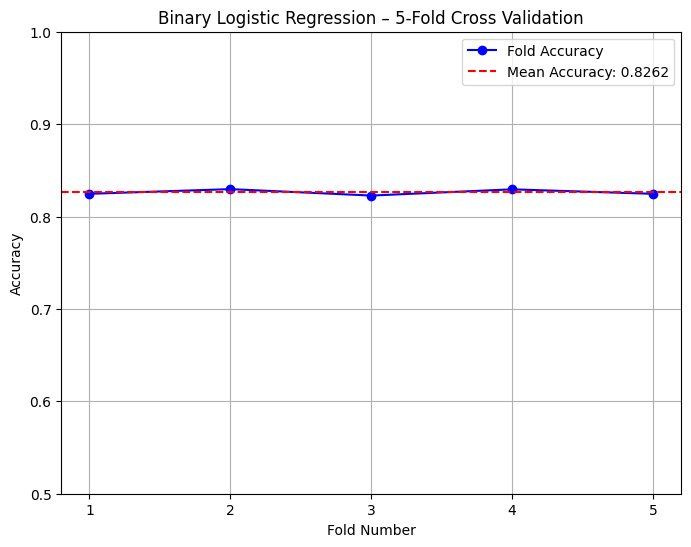

In [51]:
# Combined K-Fold Cross Validation example for the final model

from sklearn.model_selection import StratifiedKFold, cross_val_score

# Use the best feature set and C from the combined workflow above
X_cv = X[best_features]
y_cv = y

model_cv = LogisticRegression(C=best_C, solver="liblinear", max_iter=1000)

# Stratified K-Fold Cross Validation (k = 5)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model_cv, X_cv, y_cv, cv=skf, scoring="accuracy")

print("K-Fold Cross Validation (k = 5) – Accuracy per fold:")
print(cv_scores)
print(f"Mean Accuracy: {cv_scores.mean():.4f}")

plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cv_scores) + 1), cv_scores,
         marker="o", linestyle="-", color="blue", label="Fold Accuracy")
plt.axhline(y=cv_scores.mean(), color="red", linestyle="--",
            label=f"Mean Accuracy: {cv_scores.mean():.4f}")
plt.title("Binary Logistic Regression – 5-Fold Cross Validation")
plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.xticks(range(1, len(cv_scores) + 1))
plt.ylim(0.5, 1.0)
plt.legend()
plt.grid(True)
plt.show()